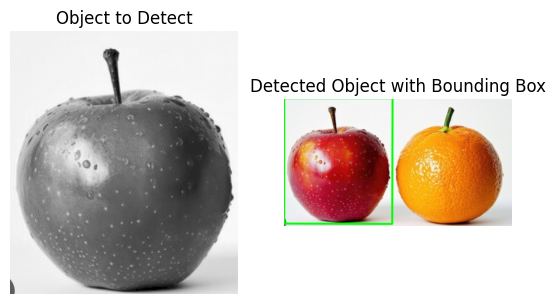

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the reference object image and the scene image
object_img = cv2.imread(r"/content/ap.png", cv2.IMREAD_GRAYSCALE)
scene_img = cv2.imread(r"/content/apor.jpg", cv2.IMREAD_GRAYSCALE)

# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints_obj, descriptors_obj = sift.detectAndCompute(object_img, None)
keypoints_scene, descriptors_scene = sift.detectAndCompute(scene_img, None)

# Match descriptors using FLANN-based matcher
flann_index_kdtree = 1
index_params = dict(algorithm=flann_index_kdtree, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(descriptors_obj, descriptors_scene, k=2)

# Apply Lowe's ratio test to keep only good matches
good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

# Convert scene image to color for visualization
scene_img_bgr = cv2.imread(r"/content/apor.jpg")

if len(good_matches) > 10:
    # Get keypoints from the good matches
    src_pts = np.float32([keypoints_obj[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints_scene[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Compute Homography to transform the object onto the scene
    matrix, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # Get the corners of the detected object
    h, w = object_img.shape
    obj_corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    scene_corners = cv2.perspectiveTransform(obj_corners, matrix)

    # Draw a bounding box around the detected object
    cv2.polylines(scene_img_bgr, [np.int32(scene_corners)], True, (0, 255, 0), 3, cv2.LINE_AA)

    # Create a mask for segmentation
    mask = np.zeros(scene_img_bgr.shape[:2], dtype=np.uint8)
    scene_corners = np.int32(scene_corners)  # Ensure integer points
    cv2.fillPoly(mask, [scene_corners], 255)

    # Apply the mask to segment the object
    segmented_object = cv2.bitwise_and(scene_img_bgr, scene_img_bgr, mask=mask)

    # Save the output images
    cv2.imwrite("detected_object.png", scene_img_bgr)
    cv2.imwrite("segmented_object.png", segmented_object)

    # Display results
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(object_img, cmap="gray")
    plt.title("Object to Detect")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(scene_img_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Detected Object with Bounding Box")
    plt.axis("off")



    plt.show()
else:
    print("Object not detected.")